# Results — Datasets 2 & 3 (Generalization)

This notebook reports results for the generalization experiment, testing whether the pipeline transfers to unseen datasets beyond the exploratory Monkeypox set.

**Dataset 2:** English generalization set (October 2025)  
**Dataset 3:** German generalization set (October 2025)  
**LLMs evaluated:** DeepSeek  
**Embedding models:** Gemma, BGE-M3, BERTweet  
**Baseline:** BM25

In [6]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import pyarrow.parquet as pq

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

from utils import load_experiment_results, load_human_posts, load_llm_generations

LLM_NAMES  = ["deepseek"]
EMBEDDING  = "gemma"
SCORER     = "bertweet_large"
M_RETR     = 200
K_VALUES   = [5, 10, 15, 20, 25]

LABEL_ORDER = ["FALSE", "TRUE", "OTHER"]
PALETTE     = {"FALSE": "#D55E00", "TRUE": "#009E73", "OTHER": "#0072B2"}
LLM_PALETTE = {"deepseek": "#CC79A7", "gemini": "#56B4E9", "gpt": "#008080"}
STYLES      = {
    "Gemma":    ("#4EAFD4", "o", "-"),
    "BERTweet": ("#E8651A", "^", "-"),
    "BGE-M3":   ("#27AE60", "s", "-"),
    "BM25":     ("#555555", "P", "-"),
}
EMBEDDING_MODELS = {"gemma": "Gemma", "bertweet": "BERTweet", "bge-m3": "BGE-M3"}

FIGSIZE          = (15, 5.5)
FONTSIZE_TITLE   = 18
FONTSIZE_AXLABEL = 18
FONTSIZE_TICK    = 15
FONTSIZE_LEGEND  = 16
FLIER_SIZE       = 3

GAIN_MAP      = {"FALSE": 1, "TRUE": 0, "OTHER": 0}
NDCG_GAIN_MAP = {"FALSE": 2, "TRUE": 0, "OTHER": 1}

def precision_at_k(df, k):
    top_k = df[df["rank"] <= k]
    return top_k["label"].map(GAIN_MAP).sum() / k

def recall_at_k(df, k):
    top_k = df[df["rank"] <= k]
    tp    = top_k["label"].map(GAIN_MAP).sum()
    total = df["label"].map(GAIN_MAP).sum()
    return tp / total if total > 0 else 0.0

def dcg(gains):
    g = gains.reset_index(drop=True)
    return float((g / np.log2(g.index + 2)).sum())

def ndcg_at_k(df, k):
    top_k_gains = df[df["rank"] <= k]["label"].map(NDCG_GAIN_MAP).reset_index(drop=True)
    ideal_gains = df["label"].map(NDCG_GAIN_MAP).sort_values(ascending=False).head(k).reset_index(drop=True)
    idcg = dcg(ideal_gains)
    return dcg(top_k_gains) / idcg if idcg > 0 else 0.0
def build_bm25_df(bm25_scores, human_posts, llm_posts):
    n_llm, n_human = bm25_scores.shape
    llm_idx   = np.repeat(np.arange(n_llm), n_human)
    human_idx = np.tile(np.arange(n_human), n_llm)
    df = pd.DataFrame({
        "llm_row_idx":   llm_idx,
        "human_row_idx": human_idx,
        "score":         bm25_scores.ravel(),
    })
    df = df.merge(human_posts[["label"]], left_on="human_row_idx", right_index=True, how="left")
    return df

---
## Dataset 2 — English Generalization Set

In [7]:
DATASET_NR  = 2
human_posts = load_human_posts(DATASET_NR)

N_HUMAN   = len(human_posts)
N_FALSE   = (human_posts["label"] == "FALSE").sum()
BASE_RATE = N_FALSE / N_HUMAN

print(f"N posts: {N_HUMAN}")
print(f"Label distribution:\n{human_posts['label'].value_counts()}")
print(f"Base FALSE rate: {BASE_RATE:.3f}")

N posts: 215
Label distribution:
label
FALSE    75
OTHER    72
TRUE     68
Name: count, dtype: int64
Base FALSE rate: 0.349


### UMAP — LLM posts projected into human semantic space

/Users/gabriellalara/Documents/TUBerlin/Module/Master/Master_Thesis/synthetic-disinfo-retrieval/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/gabriellalara/Documents/TUBerlin/Module/Master/Master_Thesis/synthetic-disinfo-retrieval/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/gabriellalara/Documents/TUBerlin/Module/Master/Master_Thesis/synthetic-disinfo-retrieval/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


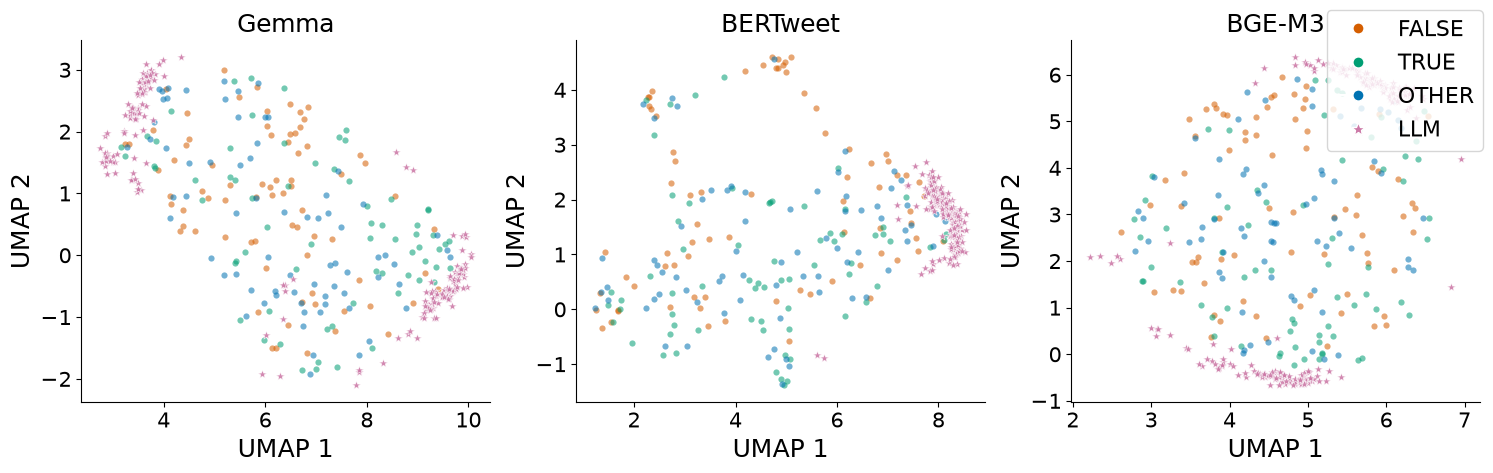

In [8]:
LLM_NAME = "deepseek"
labels   = human_posts["label"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=False, sharey=False)

for ax, (emb_key, emb_title) in zip(axes, EMBEDDING_MODELS.items()):
    emb_dir   = Path(f"data/embeddings/dataset_{DATASET_NR}/{emb_key}")
    human_emb = np.load(emb_dir / "embeddings_human.npy")
    llm_emb   = np.load(emb_dir / f"embeddings_{LLM_NAME}.npy")

    reducer  = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=42)
    human_2d = reducer.fit_transform(human_emb)
    llm_2d   = reducer.transform(llm_emb)

    for label in LABEL_ORDER:
        mask = labels == label
        ax.scatter(human_2d[mask, 0], human_2d[mask, 1],
                   c=PALETTE[label], alpha=0.55, s=20, linewidths=0, label=label)

    ax.scatter(llm_2d[:, 0], llm_2d[:, 1],
               c=LLM_PALETTE[LLM_NAME], alpha=0.88, s=42, marker="*",
               edgecolors="white", linewidths=0.4, zorder=5, label="LLM")

    ax.set_title(emb_title, fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("UMAP 1", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel("UMAP 2", fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE[l], markersize=8, label=l)
           for l in LABEL_ORDER]
handles.append(Line2D([0],[0], marker='*', color='w', markerfacecolor=LLM_PALETTE[LLM_NAME], markersize=10, label="LLM"))
fig.legend(handles=handles, loc="upper right", fontsize=FONTSIZE_LEGEND)
plt.tight_layout()
plt.show()

### PCA — LLM posts projected into human semantic space

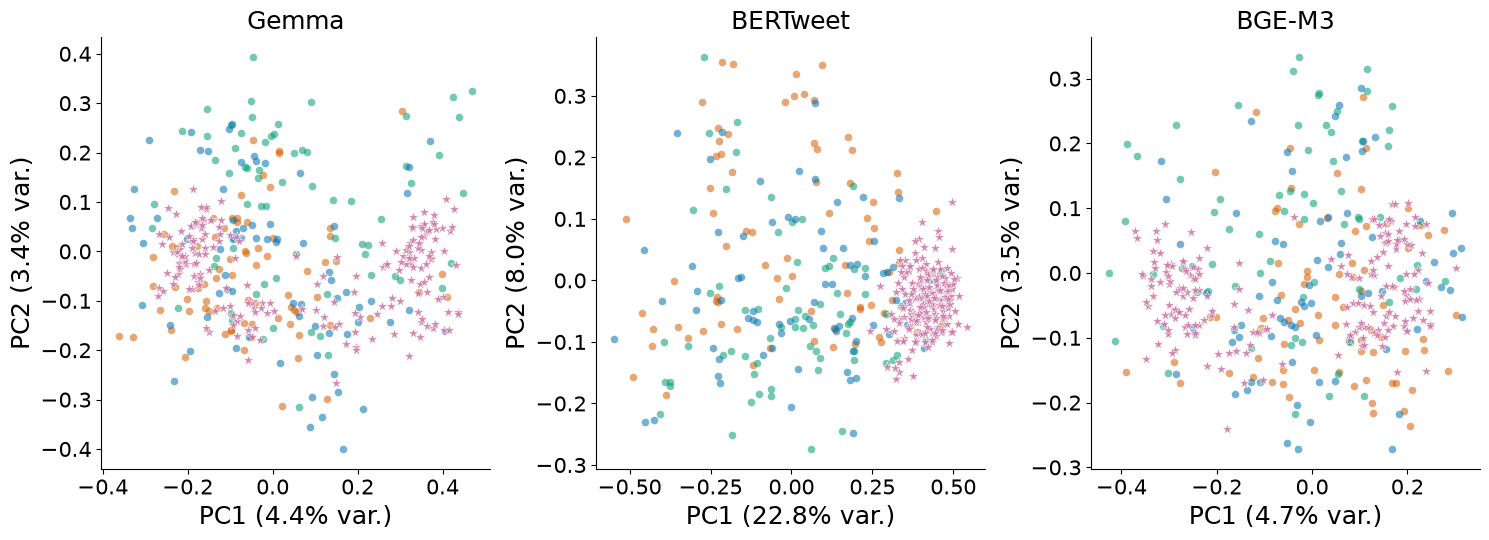

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=False, sharey=False)

for ax, (emb_key, emb_title) in zip(axes, EMBEDDING_MODELS.items()):
    emb_dir   = Path(f"data/embeddings/dataset_{DATASET_NR}/{emb_key}")
    human_emb = np.load(emb_dir / "embeddings_human.npy")
    llm_emb   = np.load(emb_dir / f"embeddings_{LLM_NAME}.npy")

    pca      = PCA(n_components=2, random_state=42)
    human_2d = pca.fit_transform(human_emb)
    llm_2d   = pca.transform(llm_emb)
    var1, var2 = pca.explained_variance_ratio_ * 100

    for label in LABEL_ORDER:
        mask = labels == label
        ax.scatter(human_2d[mask, 0], human_2d[mask, 1],
                   c=PALETTE[label], alpha=0.55, s=30, linewidths=0)

    ax.scatter(llm_2d[:, 0], llm_2d[:, 1],
               c=LLM_PALETTE[LLM_NAME], alpha=0.88, s=60, marker="*",
               edgecolors="white", linewidths=0.4, zorder=5)

    ax.set_title(emb_title, fontsize=FONTSIZE_TITLE)
    ax.set_xlabel(f"PC1 ({var1:.1f}% var.)", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel(f"PC2 ({var2:.1f}% var.)", fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### RQ2 — Flagging Performance (English)

In [10]:
llm_name = LLM_NAMES[0]
llm_posts = load_llm_generations(DATASET_NR, llm_name)

flagged_gemma    = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm_name}_embedding=gemma_reranker=none_m=all.parquet").to_pandas()
flagged_bge      = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm_name}_embedding=bge-m3_reranker=none_m=all.parquet").to_pandas()
flagged_bertweet = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm_name}_embedding=bertweet_reranker=none_m=all.parquet").to_pandas()

bm25_scores  = np.load(f"results/dataset_{DATASET_NR}/baseline_{llm_name}.npy")
bm25_full    = build_bm25_df(bm25_scores, human_posts, llm_posts)
best_idx     = bm25_full.groupby("human_row_idx")["score"].idxmax()
flagged_bm25 = (
    bm25_full.loc[best_idx, ["human_row_idx", "llm_row_idx", "score", "label"]]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
flagged_bm25["rank"] = flagged_bm25.index + 1

records_eng = []
for k in K_VALUES:
    for system, df in [
        ("Gemma",    flagged_gemma),
        ("BGE-M3",   flagged_bge),
        ("BERTweet", flagged_bertweet),
        ("BM25",     flagged_bm25),
    ]:
        records_eng.append({
            "LLM": llm_name, "System": system, "K": k,
            "Precision@K": precision_at_k(df, k),
            "nDCG@K":      ndcg_at_k(df, k),
        })

results_eng = pd.DataFrame(records_eng)
results_eng.pivot_table(index=["LLM", "System"], columns="K",
                        values=["Precision@K", "nDCG@K"]).round(3)

Precision@K                         nDCG@K                \
K                          5    10     15    20    25     5      10     15   
LLM      System                                                              
deepseek BERTweet         0.4  0.2  0.333  0.30  0.36  0.522  0.483  0.531   
         BGE-M3           0.4  0.4  0.267  0.25  0.20  0.345  0.410  0.364   
         BM25             0.0  0.3  0.200  0.25  0.24  0.073  0.334  0.328   
         Gemma            0.6  0.4  0.333  0.30  0.24  0.491  0.392  0.418   

                                 
K                     20     25  
LLM      System                  
deepseek BERTweet  0.526  0.549  
         BGE-M3    0.369  0.346  
         BM25      0.356  0.375  
         Gemma     0.414  0.385

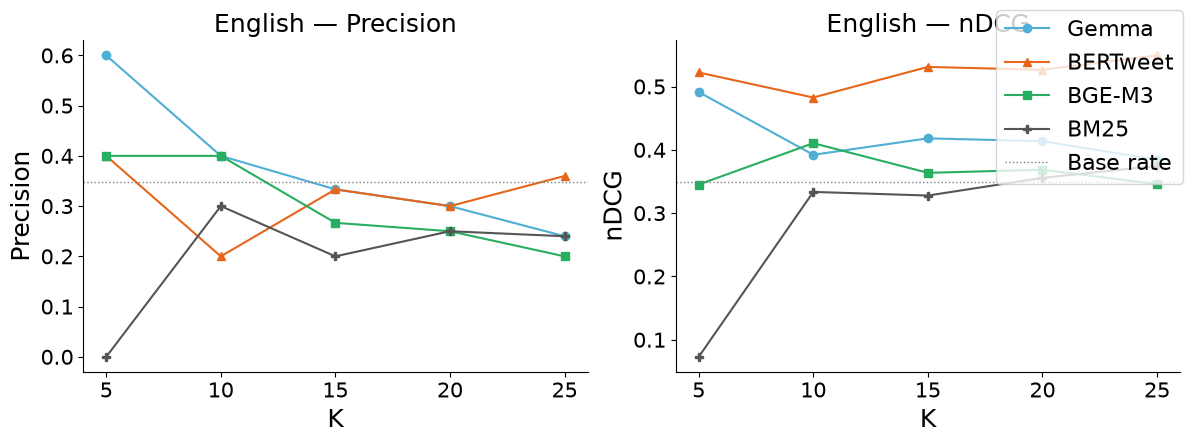

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

for ax, (metric, ylabel) in zip(axes, [("Precision@K", "Precision"), ("nDCG@K", "nDCG")]):
    for system, (color, marker, ls) in STYLES.items():
        s = results_eng[results_eng["System"] == system]
        if s.empty:
            continue
        ax.plot(s["K"], s[metric], color=color, marker=marker,
                linestyle=ls, label=system, linewidth=1.5)
    ax.axhline(BASE_RATE, color="gray", linestyle=":", linewidth=1, label="Base rate")
    ax.set_title(f"English — {ylabel}", fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("K", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="upper right", fontsize=FONTSIZE_LEGEND)
plt.tight_layout()
plt.show()

---
## Dataset 3 — German Generalization Set

In [13]:
DATASET_NR  = 3
human_posts = load_human_posts(DATASET_NR)

N_HUMAN   = len(human_posts)
N_FALSE   = (human_posts["label"] == "FALSE").sum()
BASE_RATE = N_FALSE / N_HUMAN

print(f"N posts: {N_HUMAN}")
print(f"Label distribution:\n{human_posts['label'].value_counts()}")
print(f"Base FALSE rate: {BASE_RATE:.3f}")

N posts: 214
Label distribution:
label
TRUE     106
OTHER     56
FALSE     52
Name: count, dtype: int64
Base FALSE rate: 0.243


### UMAP — LLM posts projected into human semantic space (German)

/Users/gabriellalara/Documents/TUBerlin/Module/Master/Master_Thesis/synthetic-disinfo-retrieval/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/gabriellalara/Documents/TUBerlin/Module/Master/Master_Thesis/synthetic-disinfo-retrieval/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/gabriellalara/Documents/TUBerlin/Module/Master/Master_Thesis/synthetic-disinfo-retrieval/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


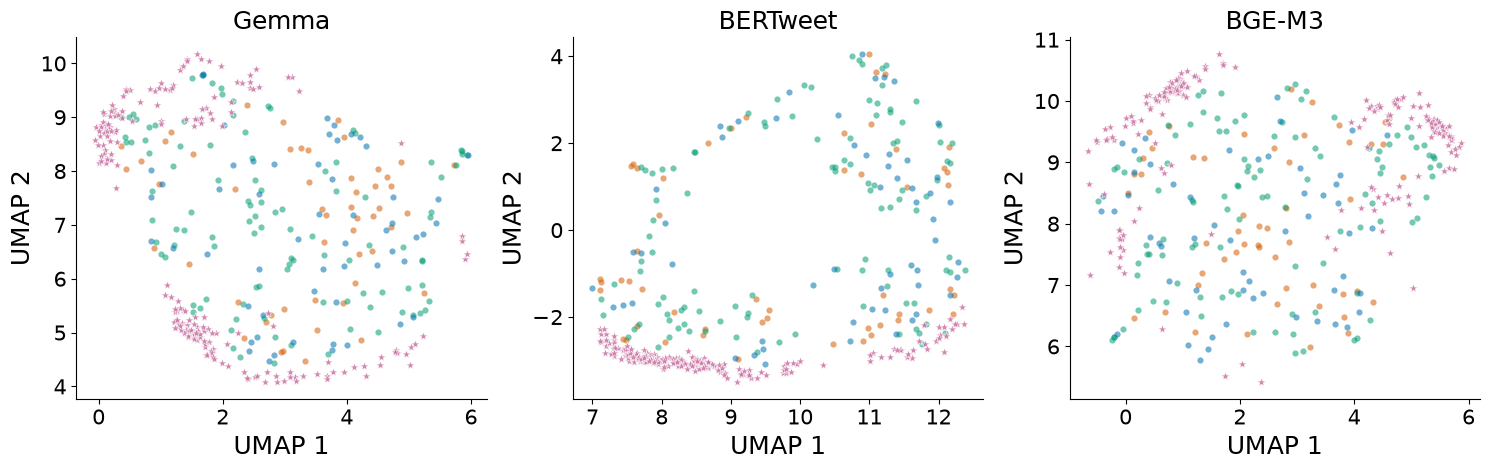

In [14]:
labels = human_posts["label"].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=False, sharey=False)

for ax, (emb_key, emb_title) in zip(axes, EMBEDDING_MODELS.items()):
    emb_dir   = Path(f"data/embeddings/dataset_{DATASET_NR}/{emb_key}")
    human_emb = np.load(emb_dir / "embeddings_human.npy")
    llm_emb   = np.load(emb_dir / f"embeddings_{LLM_NAME}.npy")

    reducer  = umap.UMAP(n_neighbors=10, min_dist=0.1, metric="cosine", random_state=42)
    human_2d = reducer.fit_transform(human_emb)
    llm_2d   = reducer.transform(llm_emb)

    for label in LABEL_ORDER:
        mask = labels == label
        ax.scatter(human_2d[mask, 0], human_2d[mask, 1],
                   c=PALETTE[label], alpha=0.55, s=20, linewidths=0)

    ax.scatter(llm_2d[:, 0], llm_2d[:, 1],
               c=LLM_PALETTE[LLM_NAME], alpha=0.88, s=42, marker="*",
               edgecolors="white", linewidths=0.4, zorder=5)

    ax.set_title(emb_title, fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("UMAP 1", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel("UMAP 2", fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### RQ2 — Flagging Performance (German)

In [15]:
llm_name = LLM_NAMES[0]
llm_posts = load_llm_generations(DATASET_NR, llm_name)

flagged_gemma    = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm_name}_embedding=gemma_reranker=none_m=all.parquet").to_pandas()
flagged_bge      = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm_name}_embedding=bge-m3_reranker=none_m=all.parquet").to_pandas()
flagged_bertweet = pq.read_table(f"results/dataset_{DATASET_NR}/aggregation/flagged_llm={llm_name}_embedding=bertweet_reranker=none_m=all.parquet").to_pandas()

bm25_scores  = np.load(f"results/dataset_{DATASET_NR}/baseline_{llm_name}.npy")
bm25_full    = build_bm25_df(bm25_scores, human_posts, llm_posts)
best_idx     = bm25_full.groupby("human_row_idx")["score"].idxmax()
flagged_bm25 = (
    bm25_full.loc[best_idx, ["human_row_idx", "llm_row_idx", "score", "label"]]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
flagged_bm25["rank"] = flagged_bm25.index + 1

records_ger = []
for k in K_VALUES:
    for system, df in [
        ("Gemma",    flagged_gemma),
        ("BGE-M3",   flagged_bge),
        ("BERTweet", flagged_bertweet),
        ("BM25",     flagged_bm25),
    ]:
        records_ger.append({
            "LLM": llm_name, "System": system, "K": k,
            "Precision@K": precision_at_k(df, k),
            "nDCG@K":      ndcg_at_k(df, k),
        })

results_ger = pd.DataFrame(records_ger)
results_ger.pivot_table(index=["LLM", "System"], columns="K",
                        values=["Precision@K", "nDCG@K"]).round(3)

Precision@K                         nDCG@K                \
K                          5    10     15    20    25     5      10     15   
LLM      System                                                              
deepseek BERTweet         0.2  0.4  0.400  0.40  0.40  0.384  0.503  0.502   
         BGE-M3           0.0  0.1  0.133  0.15  0.16  0.073  0.188  0.190   
         BM25             0.2  0.2  0.267  0.20  0.24  0.146  0.193  0.262   
         Gemma            0.0  0.2  0.200  0.15  0.20  0.235  0.282  0.289   

                                 
K                     20     25  
LLM      System                  
deepseek BERTweet  0.535  0.557  
         BGE-M3    0.191  0.232  
         BM25      0.252  0.272  
         Gemma     0.258  0.277

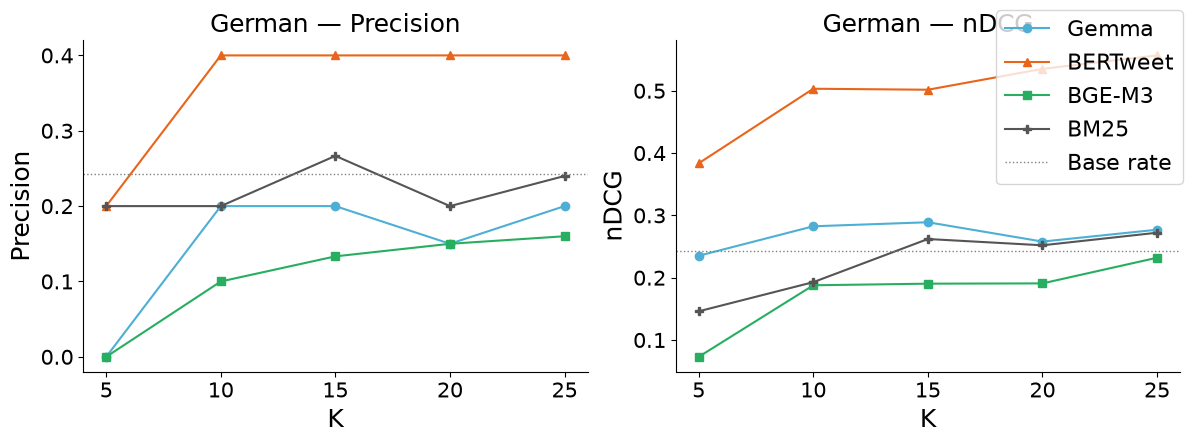

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

for ax, (metric, ylabel) in zip(axes, [("Precision@K", "Precision"), ("nDCG@K", "nDCG")]):
    for system, (color, marker, ls) in STYLES.items():
        s = results_ger[results_ger["System"] == system]
        if s.empty:
            continue
        ax.plot(s["K"], s[metric], color=color, marker=marker,
                linestyle=ls, label=system, linewidth=1.5)
    ax.axhline(BASE_RATE, color="gray", linestyle=":", linewidth=1, label="Base rate")
    ax.set_title(f"German — {ylabel}", fontsize=FONTSIZE_TITLE)
    ax.set_xlabel("K", fontsize=FONTSIZE_AXLABEL)
    ax.set_ylabel(ylabel, fontsize=FONTSIZE_AXLABEL)
    ax.tick_params(labelsize=FONTSIZE_TICK)
    sns.despine(ax=ax)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="upper right", fontsize=FONTSIZE_LEGEND)
plt.tight_layout()
plt.show()

---
## Qualitative Analysis — LLM-as-a-Judge

See **`03_qualitative_results.ipynb`** for the full qualitative evaluation, including inter-judge agreement (GPT vs Claude), scores by language × system, scores by label, and averaged results.